# Three-bin GEDF reconstruction and model comparison

This notebook uses GetDist chains with prefix `260817_gedf_3bins_test_02` to reconstruct the three-bin $w(z)$ and $f_{\rm gedf}(z)=\rho_{\rm gedf}/\rho_{\rm tot}$. It then compares them with the earlier model-independent reconstruction on the same redshift grid.

In [1]:
from pathlib import Path
import os
import subprocess
import tempfile

os.environ.setdefault("XDG_CACHE_HOME", "/tmp/getdist-cache-3bins")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-gedf-3bins")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getdist import loadMCSamples

PROJECT_DIR = Path("/home/lutein/Projects/class-gedf-test-04")
THREEBIN_CLASS_DIR = Path("/home/lutein/Projects/class-gedf-3bins")
CHAIN_ROOT = Path(
    "/home/lutein/jupyter/Chains/260818_gedf_3bins/"
    "260817_gedf_3bins_test_02"
)
PREVIOUS_RESULTS = PROJECT_DIR / "notebooks/model_independent_reconstruction_results.npz"
WORKER = PROJECT_DIR / "notebooks/gedf_3bins_class_worker.py"
PYTHON312 = Path("/home/lutein/anaconda3/envs/test_env_py312/bin/python")
THREEBIN_PYTHONPATH = (
    THREEBIN_CLASS_DIR / "build/lib.linux-x86_64-cpython-312"
)
BURN_IN = 0.30
F_GEDF_DRAWS = 256

for required in [THREEBIN_CLASS_DIR, PREVIOUS_RESULTS, WORKER, PYTHON312, THREEBIN_PYTHONPATH]:
    assert required.exists(), required
print(f"Three-bin CLASS: {THREEBIN_CLASS_DIR}")
print(f"Chain root:       {CHAIN_ROOT}")

Three-bin CLASS: /home/lutein/Projects/class-gedf-3bins
Chain root:       /home/lutein/jupyter/Chains/260818_gedf_3bins/260817_gedf_3bins_test_02


## GetDist posterior summary

As in the previous reconstruction, the first 30% of each chain is removed as burn-in.

In [2]:
samples_3bin = loadMCSamples(
    str(CHAIN_ROOT), no_cache=True, settings={"ignore_rows": BURN_IN}
)
parameter_names = [
    "omega_b", "omega_cdm", "theta_s_1e2", "logA", "A_s",
    "n_s", "tau_reio", "w_1", "w_2", "w_3",
    "log10z_12", "log10z_23", "z_12", "z_23", "f_gedf",
    "H0", "sigma8", "Omega_m",
]
summary_3bin = pd.DataFrame(
    {
        "mean": [samples_3bin.mean(name) for name in parameter_names],
        "std (1 sigma)": [samples_3bin.std(name) for name in parameter_names],
    },
    index=parameter_names,
)
summary_3bin.index.name = "parameter"
print(f"Post-burn-in rows: {samples_3bin.numrows:,}")
print(f"Total sample weight: {samples_3bin.weights.sum():,.0f}")
summary_3bin

/home/lutein/jupyter/Chains/260818_gedf_3bins/260817_gedf_3bins_test_02.1.txt
/home/lutein/jupyter/Chains/260818_gedf_3bins/260817_gedf_3bins_test_02.2.txt
/home/lutein/jupyter/Chains/260818_gedf_3bins/260817_gedf_3bins_test_02.3.txt
/home/lutein/jupyter/Chains/260818_gedf_3bins/260817_gedf_3bins_test_02.4.txt
Removed 0.3 as burn in
Post-burn-in rows: 122,615
Total sample weight: 123,338


,mean,std (1 sigma)
parameter,,
omega_b,2.303934e-02,1.499376e-04
omega_cdm,1.292958e-01,2.899472e-03
theta_s_1e2,1.041154e+00,2.755618e-04
logA,3.080948e+00,1.424892e-02
A_s,2.178124e-09,3.103211e-11
n_s,9.934469e-01,5.139306e-03
tau_reio,6.242283e-02,6.211891e-03
w_1,-8.050936e-01,1.086087e-01
w_2,1.046143e+00,6.240246e-01


## Three-bin $w(z)$ posterior

The branch uses two exponential transitions with fixed $q_{\rm gedf}=20$. The analytic vectorization below is the equation implemented by `background_w_gedf`; all weighted chain samples are used for the pointwise moments.

In [3]:
Q_GEDF = 20.0
z = np.linspace(500.0, 6000.0, 451)
W3_NAMES = ["w_1", "w_2", "w_3", "z_12", "z_23"]
W3_COLUMNS = [samples_3bin.index[name] for name in W3_NAMES]

def threebin_w_curves(z_values, parameters):
    values = np.atleast_2d(np.asarray(parameters, dtype=float))
    z_values = np.asarray(z_values, dtype=float)
    w1, w2, w3, z12, z23 = (values[:, i] for i in range(5))
    result = w1[:, None].copy() * np.ones((1, z_values.size))
    for delta_w, transition_z in [(w2 - w1, z12), (w3 - w2, z23)]:
        log_t = (
            np.log(np.log(2.0))
            + Q_GEDF * (
                np.log1p(transition_z)[:, None] - np.log1p(z_values)[None, :]
            )
        )
        saturated = log_t > np.log(-np.log(np.finfo(float).tiny))
        t = np.exp(np.clip(log_t, -745.0, 7.0))
        transition_fraction = np.where(saturated, 1.0, -np.expm1(-t))
        result += delta_w[:, None] * transition_fraction
    return result

def weighted_threebin_w_moments(chunk_size=5000):
    total = np.zeros_like(z)
    total_sq = np.zeros_like(z)
    total_weight = 0.0
    for start in range(0, samples_3bin.numrows, chunk_size):
        stop = min(start + chunk_size, samples_3bin.numrows)
        weights = samples_3bin.weights[start:stop]
        curves = threebin_w_curves(
            z, samples_3bin.samples[start:stop, W3_COLUMNS]
        )
        total += weights @ curves
        total_sq += weights @ (curves * curves)
        total_weight += weights.sum()
    mean = total / total_weight
    variance = np.maximum(total_sq / total_weight - mean * mean, 0.0)
    return mean, np.sqrt(variance)

w_3bin_mean, w_3bin_std = weighted_threebin_w_moments()
print(f"Computed w(z) from all {samples_3bin.numrows:,} post-burn-in rows.")

Computed w(z) from all 122,615 post-burn-in rows.


## Direct 3-bin CLASS evaluation of $w(z)$ and $f_{\rm gedf}(z)$

The supplied wrapper is compiled for Python 3.12, so this `test_env_01` notebook launches one ABI-matched helper process. The first evaluation is at the GetDist mean parameters for validation; the remaining 256 evaluations are a fixed-seed weighted posterior resample used for the fractional-density band.

In [4]:
CLASS_PARAMETER_NAMES = [
    "H0", "omega_b", "omega_cdm", "w_1", "w_2", "w_3",
    "z_12", "z_23", "f_gedf",
]
rng = np.random.default_rng(26082603)
draw_indices = rng.choice(
    samples_3bin.numrows, size=F_GEDF_DRAWS, replace=True,
    p=samples_3bin.weights / samples_3bin.weights.sum(),
)
payload = {"z": z}
for name in CLASS_PARAMETER_NAMES:
    column = samples_3bin.index[name]
    payload[name] = np.concatenate([
        [samples_3bin.mean(name)],
        samples_3bin.samples[draw_indices, column],
    ])

gsl_compat = Path("/tmp/libgsl.so.0")
if not gsl_compat.exists():
    gsl_compat.symlink_to("/lib/x86_64-linux-gnu/libgsl.so.27")
worker_env = os.environ.copy()
worker_env["PYTHONPATH"] = str(THREEBIN_PYTHONPATH)
worker_env["LD_LIBRARY_PATH"] = "/tmp"
with tempfile.TemporaryDirectory(prefix="gedf-3bins-") as temp_dir:
    input_path = Path(temp_dir) / "input.npz"
    output_path = Path(temp_dir) / "output.npz"
    np.savez(input_path, **payload)
    completed = subprocess.run(
        [str(PYTHON312), str(WORKER), str(input_path), str(output_path)],
        env=worker_env, check=True, text=True, capture_output=True,
    )
    print(completed.stdout.strip())
    with np.load(output_path) as class_output:
        class_w_3bin = class_output["w_curves"].copy()
        class_f_3bin = class_output["f_curves"].copy()
        class_derived_f = class_output["derived_f"].copy()

mean_w_parameters = np.array([samples_3bin.mean(name) for name in W3_NAMES])
direct_mean_parameter_w = threebin_w_curves(z, mean_w_parameters)[0]
max_abs_error = np.max(np.abs(class_w_3bin[0] - direct_mean_parameter_w))
print(f"Maximum |w_CLASS - w_reconstruction| = {max_abs_error:.3e}")
assert max_abs_error < 2e-5

f_3bin_mean = class_f_3bin[1:].mean(axis=0)
f_3bin_std = class_f_3bin[1:].std(axis=0)
print(
    f"CLASS shooting check: max |derived f_gedf - requested f_gedf| = "
    f"{np.max(np.abs(class_derived_f - payload['f_gedf'])):.3e}"
)

CLASS backgrounds completed: 64/257
CLASS backgrounds completed: 128/257
CLASS backgrounds completed: 192/257
CLASS backgrounds completed: 256/257
CLASS backgrounds completed: 257/257
Maximum |w_CLASS - w_reconstruction| = 1.209e-05
CLASS shooting check: max |derived f_gedf - requested f_gedf| = 9.791e-08


## Three-bin reconstruction plots

Saved /home/lutein/Projects/class-gedf-test-04/notebooks/wz_3bins_mcmc_mean_1sigma.png


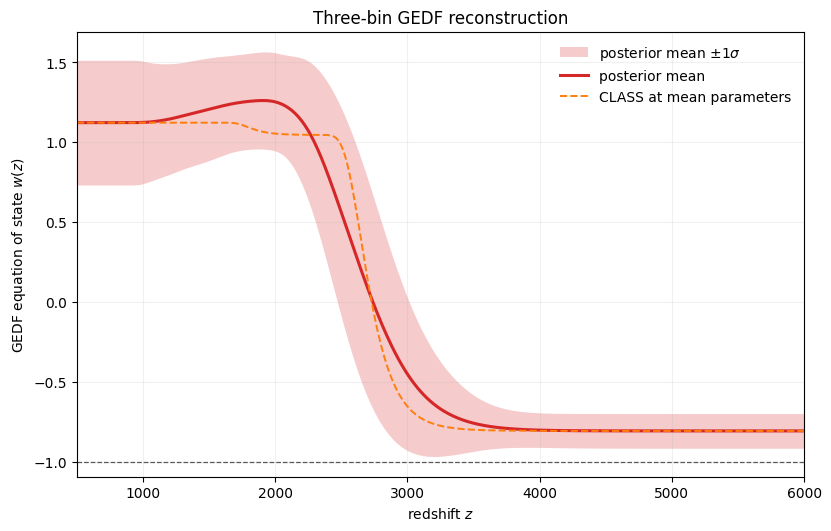

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
ax.fill_between(z, w_3bin_mean - w_3bin_std, w_3bin_mean + w_3bin_std,
                color="C3", alpha=0.24, linewidth=0,
                label=r"posterior mean $\pm1\sigma$")
ax.plot(z, w_3bin_mean, color="C3", lw=2.2, label="posterior mean")
ax.plot(z, class_w_3bin[0], color="C1", lw=1.4, ls="--",
        label="CLASS at mean parameters")
ax.axhline(-1.0, color="0.35", lw=0.9, ls="--")
ax.set(xlabel="redshift $z$", ylabel=r"GEDF equation of state $w(z)$",
       xlim=(z.min(), z.max()), title="Three-bin GEDF reconstruction")
ax.legend(frameon=False)
ax.grid(alpha=0.18)
w_3bin_path = PROJECT_DIR / "notebooks/wz_3bins_mcmc_mean_1sigma.png"
fig.savefig(w_3bin_path, dpi=180)
print(f"Saved {w_3bin_path}")
plt.show()

Saved /home/lutein/Projects/class-gedf-test-04/notebooks/f_gedf_z_3bins_mcmc_mean_1sigma.png


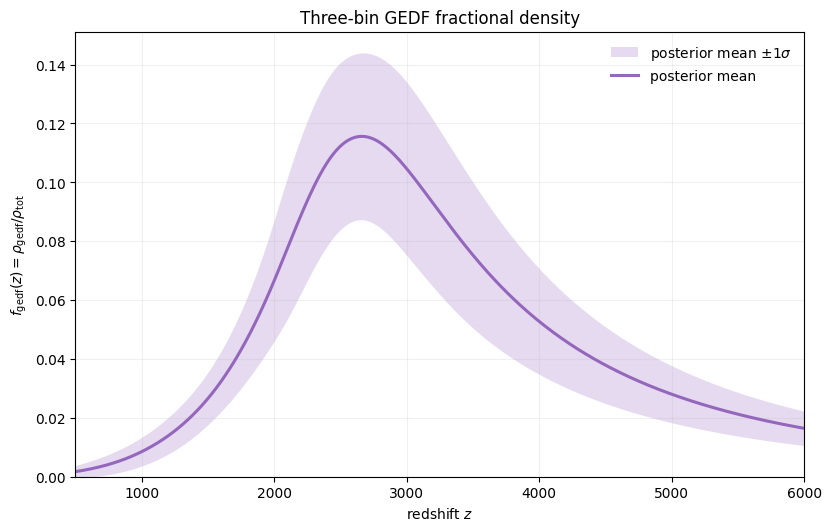

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
ax.fill_between(z, f_3bin_mean - f_3bin_std, f_3bin_mean + f_3bin_std,
                color="C4", alpha=0.24, linewidth=0,
                label=r"posterior mean $\pm1\sigma$")
ax.plot(z, f_3bin_mean, color="C4", lw=2.2, label="posterior mean")
ax.set(xlabel="redshift $z$",
       ylabel=r"$f_{\rm gedf}(z)=\rho_{\rm gedf}/\rho_{\rm tot}$",
       xlim=(z.min(), z.max()), title="Three-bin GEDF fractional density")
ax.set_ylim(bottom=0.0)
ax.legend(frameon=False)
ax.grid(alpha=0.18)
f_3bin_path = PROJECT_DIR / "notebooks/f_gedf_z_3bins_mcmc_mean_1sigma.png"
fig.savefig(f_3bin_path, dpi=180)
print(f"Saved {f_3bin_path}")
plt.show()

## Three-bin versus model-independent reconstruction

Both panels use the same redshift grid and show pointwise posterior means and standard deviations.

Saved /home/lutein/Projects/class-gedf-test-04/notebooks/gedf_3bins_vs_model_independent.png


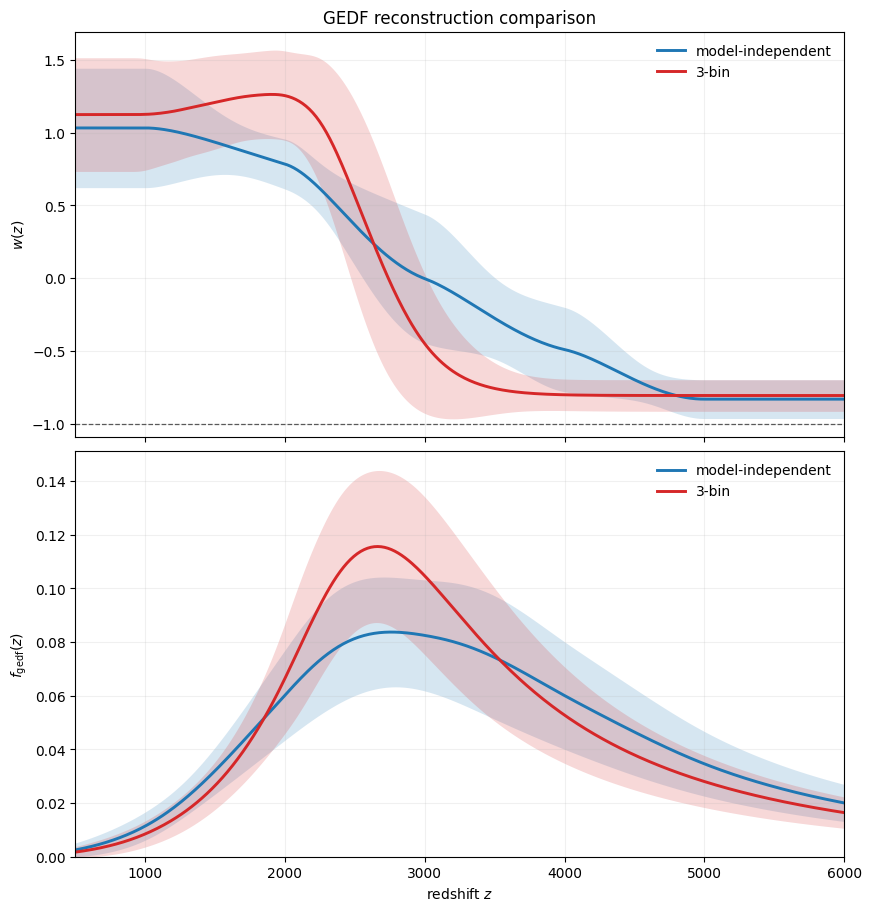

Saved /home/lutein/Projects/class-gedf-test-04/notebooks/gedf_3bins_reconstruction_results.npz


In [7]:
with np.load(PREVIOUS_RESULTS) as previous:
    assert np.allclose(previous["z"], z)
    previous_w_mean = previous["w_mean"].copy()
    previous_w_std = previous["w_std"].copy()
    previous_f_mean = previous["f_mean"].copy()
    previous_f_std = previous["f_std"].copy()

fig, (ax_w, ax_f) = plt.subplots(
    2, 1, figsize=(8.6, 9.0), sharex=True, constrained_layout=True
)

ax_w.fill_between(z, previous_w_mean - previous_w_std,
                  previous_w_mean + previous_w_std, color="C0",
                  alpha=0.18, linewidth=0)
ax_w.plot(z, previous_w_mean, color="C0", lw=2.1,
          label="model-independent")
ax_w.fill_between(z, w_3bin_mean - w_3bin_std, w_3bin_mean + w_3bin_std,
                  color="C3", alpha=0.18, linewidth=0)
ax_w.plot(z, w_3bin_mean, color="C3", lw=2.1, label="3-bin")
ax_w.axhline(-1.0, color="0.35", lw=0.9, ls="--")
ax_w.set(ylabel=r"$w(z)$", title="GEDF reconstruction comparison")
ax_w.legend(frameon=False)
ax_w.grid(alpha=0.18)

ax_f.fill_between(z, previous_f_mean - previous_f_std,
                  previous_f_mean + previous_f_std, color="C0",
                  alpha=0.18, linewidth=0)
ax_f.plot(z, previous_f_mean, color="C0", lw=2.1,
          label="model-independent")
ax_f.fill_between(z, f_3bin_mean - f_3bin_std, f_3bin_mean + f_3bin_std,
                  color="C3", alpha=0.18, linewidth=0)
ax_f.plot(z, f_3bin_mean, color="C3", lw=2.1, label="3-bin")
ax_f.set(xlabel="redshift $z$",
         ylabel=r"$f_{\rm gedf}(z)$", xlim=(z.min(), z.max()))
ax_f.set_ylim(bottom=0.0)
ax_f.legend(frameon=False)
ax_f.grid(alpha=0.18)

comparison_path = PROJECT_DIR / "notebooks/gedf_3bins_vs_model_independent.png"
fig.savefig(comparison_path, dpi=180)
print(f"Saved {comparison_path}")
plt.show()

results_path = PROJECT_DIR / "notebooks/gedf_3bins_reconstruction_results.npz"
np.savez(results_path, z=z, w_mean=w_3bin_mean, w_std=w_3bin_std,
         f_mean=f_3bin_mean, f_std=f_3bin_std, burn_in=BURN_IN,
         f_class_draws=F_GEDF_DRAWS)
print(f"Saved {results_path}")